In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
#Data Trade Data cleaned
df = pd.read_excel("Cleaned_Trade_Data.xlsx")

In [2]:
df

,Year,Country,partner_name,trade_flow,product_code,product_description,Trade Value,Quantity,netWgt,altQtyUnitAbbr,...,Customs Score,Infrastructure Score,International Shipments Score,Logistics Competence and Quality Score,Tracking and Tracing Score,Timeliness Score,Export,Import,Total_Trade,Trade_Balance
0,2016,India,thailand,Import,847130,"Automatic data processing machines; portable, ...",2671.000,3.000,14.000,NaN,...,3.105066,3.123670,3.366940,3.135446,3.203620,3.559929,2.240748e+07,1.051312e+08,1.275386e+08,-8.272368e+07
1,2016,India,ethiopia,Import,847130,"Automatic data processing machines; portable, ...",740.000,2.000,4.000,NaN,...,2.598943,2.117674,2.562729,2.367674,2.178113,2.370804,2.240748e+07,1.051312e+08,1.275386e+08,-8.272368e+07
2,2016,India,qatar,Import,847130,"Automatic data processing machines; portable, ...",2279.000,2.000,12.000,NaN,...,3.551227,3.568039,3.582678,3.543672,3.503401,3.832534,2.240748e+07,1.051312e+08,1.275386e+08,-8.272368e+07
3,2016,India,croatia,Import,847130,"Automatic data processing machines; portable, ...",835.000,1.000,4.000,NaN,...,3.074242,2.989697,3.115366,3.214506,3.164506,3.389019,2.240748e+07,1.051312e+08,1.275386e+08,-8.272368e+07
4,2016,India,indonesia,Import,847130,"Automatic data processing machines; portable, ...",383.000,1.000,2.000,NaN,...,2.688429,2.645161,2.901908,3.000057,3.192365,3.459917,2.240748e+07,1.051312e+08,1.275386e+08,-8.272368e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26590,2024,India,"hong kong sar, china",Import,848180,"Taps, cocks, valves and similar appliances; fo...",88.803,4.311,4.311,kg,...,3.800000,4.000000,4.000000,4.000000,4.200000,4.100000,4.711826e+07,7.770336e+07,1.248216e+08,-3.058510e+07
26591,2024,India,costa rica,Import,848180,"Taps, cocks, valves and similar appliances; fo...",536.593,26.049,26.049,kg,...,2.800000,2.700000,2.800000,2.900000,2.900000,3.200000,4.711826e+07,7.770336e+07,1.248216e+08,-3.058510e+07
26592,2024,India,bulgaria,Import,848180,"Taps, cocks, valves and similar appliances; fo...",710.244,34.479,34.479,kg,...,3.100000,3.100000,3.000000,3.300000,3.300000,3.500000,4.711826e+07,7.770336e+07,1.248216e+08,-3.058510e+07
26593,2024,India,bulgaria,Import,848180,"Taps, cocks, valves and similar appliances; fo...",725.176,35.204,35.204,kg,...,3.100000,3.100000,3.000000,3.300000,3.300000,3.500000,4.711826e+07,7.770336e+07,1.248216e+08,-3.058510e+07


In [3]:
print(df.describe())

               Year   product_code   Trade Value      Quantity        netWgt  \
count  26595.000000   26595.000000  2.659500e+04  2.659500e+04  2.421000e+04   
mean    2020.814890  630617.328182  7.380123e+07  1.162176e+08  1.271181e+08   
std        2.676412  260071.084427  9.625935e+08  1.763927e+09  1.848337e+09   
min     2016.000000  270900.000000  1.910000e-01  0.000000e+00  0.000000e+00   
25%     2019.000000  310210.000000  1.462183e+04  6.000000e+01  1.347180e+02   
50%     2021.000000  760110.000000  1.872168e+05  1.052700e+04  1.622661e+04   
75%     2023.000000  848180.000000  2.819482e+06  4.618040e+05  4.397024e+05   
max     2024.000000  901890.000000  5.272789e+10  9.200886e+10  9.200886e+10   

       LPI_Merge_Year     LPI Score  Customs Score  Infrastructure Score  \
count    26595.000000  22729.000000   22729.000000          22729.000000   
mean      2019.650085      3.259585       3.053938              3.215625   
std          2.793026      0.622729       0.653703 

In [4]:
country_trade = df.groupby('Country')['Total_Trade'].sum().sort_values(ascending=False)
print(country_trade.head(10))
#Total trade by India: 4.452280e+12

Country
India    4.452280e+12
Name: Total_Trade, dtype: float64


Year
2016    2.714022e+11
2017    3.496974e+11
2018    4.591797e+11
2019    4.288689e+11
2020    3.146654e+11
2021    5.164781e+11
2022    7.842971e+11
2023    6.763725e+11
2024    6.513192e+11
Name: Total_Trade, dtype: float64


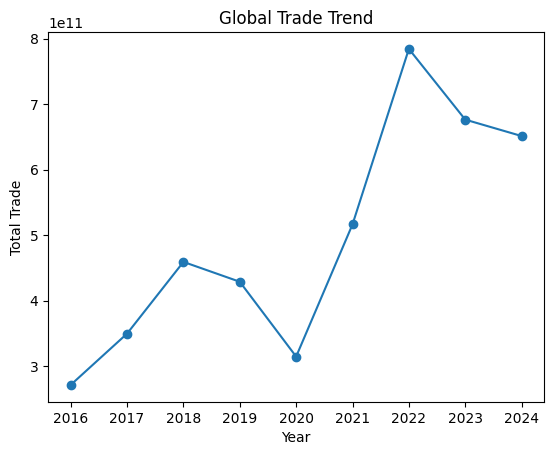

In [5]:
year_trade = df.groupby('Year')['Total_Trade'].sum()
print(year_trade)

year_trade.plot(kind='line', marker='o')
plt.title("Global Trade Trend")
plt.xlabel("Year")
plt.ylabel("Total Trade")
plt.show()
#this plot shows the Trade trend of each year.
#we see that during covid in 2020 the international trade was all time low
#and after Covid-19 in 2021 the trade has performed better than pre-covid time.

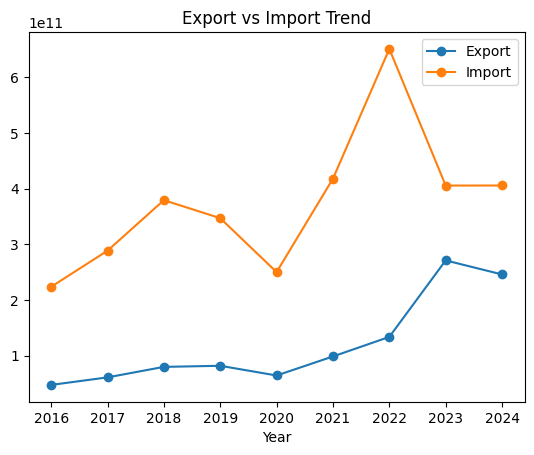

In [6]:
df.groupby('Year')[['Export','Import']].sum().plot(kind='line', marker='o')
plt.title("Export vs Import Trend")
plt.show()
#in this graph we see every year we import more than export making the currency of India weak.

In [7]:
df['Trade_Balance'] = df['Export'] - df['Import']

print(df[['Country','Year','Trade_Balance']].head())
#The trade balance is negative for every year showing that india imports more than export by a factor of 10^7 approximatiately each year

  Country  Year  Trade_Balance
0   India  2016  -8.272368e+07
1   India  2016  -8.272368e+07
2   India  2016  -8.272368e+07
3   India  2016  -8.272368e+07
4   India  2016  -8.272368e+07


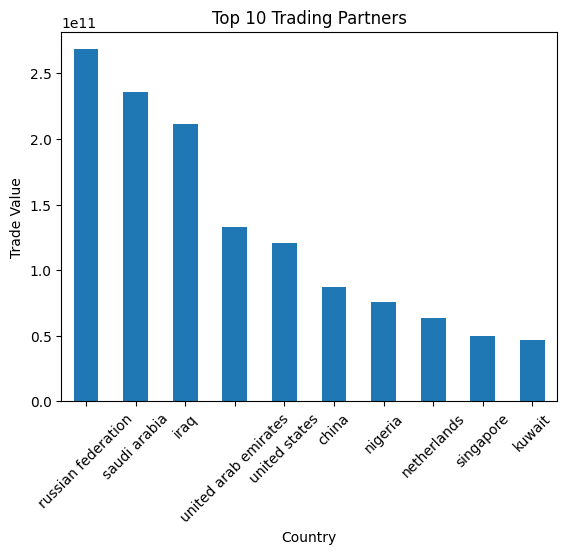

In [8]:
top_countries = df.groupby('partner_name')['Trade Value'].sum() \
                  .sort_values(ascending=False).head(10)

plt.figure()
top_countries.plot(kind='bar')
plt.title("Top 10 Trading Partners")
plt.xlabel("Country")
plt.ylabel("Trade Value")
plt.xticks(rotation=45)
plt.show()
#The graph below shows us that we trade the most with Russia, Saudi arabia and Iraq which is likely due to their availability of oil supply.

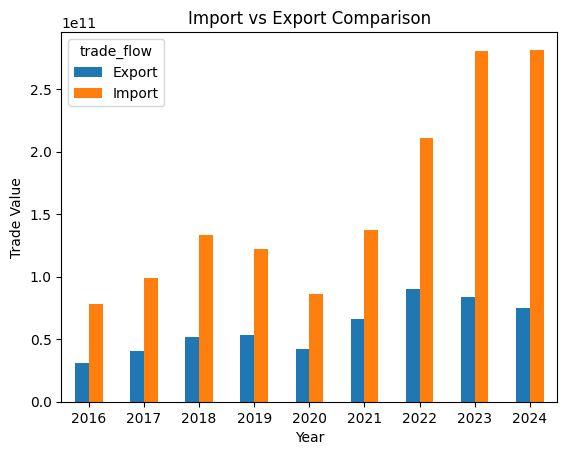

In [9]:
flow = df.groupby(['Year', 'trade_flow'])['Trade Value'].sum().unstack()

flow.plot(kind='bar')
plt.title("Import vs Export Comparison")
plt.xlabel("Year")
plt.ylabel("Trade Value")
plt.xticks(rotation=0)
plt.show()
#another graph showing trade was all time low around 2020 and every year we import more than we export

In [10]:
features = [
    'LPI Score',
    'Customs Score',
    'Infrastructure Score',
    'Logistics Competence and Quality Score',
    'Tracking and Tracing Score',
    'Timeliness Score',
    'Export',   # keep one or two only
    'Trade_Balance'
]

df_selected = df[features]

corr = df_selected.corr()
#selecting just the important features for correlation

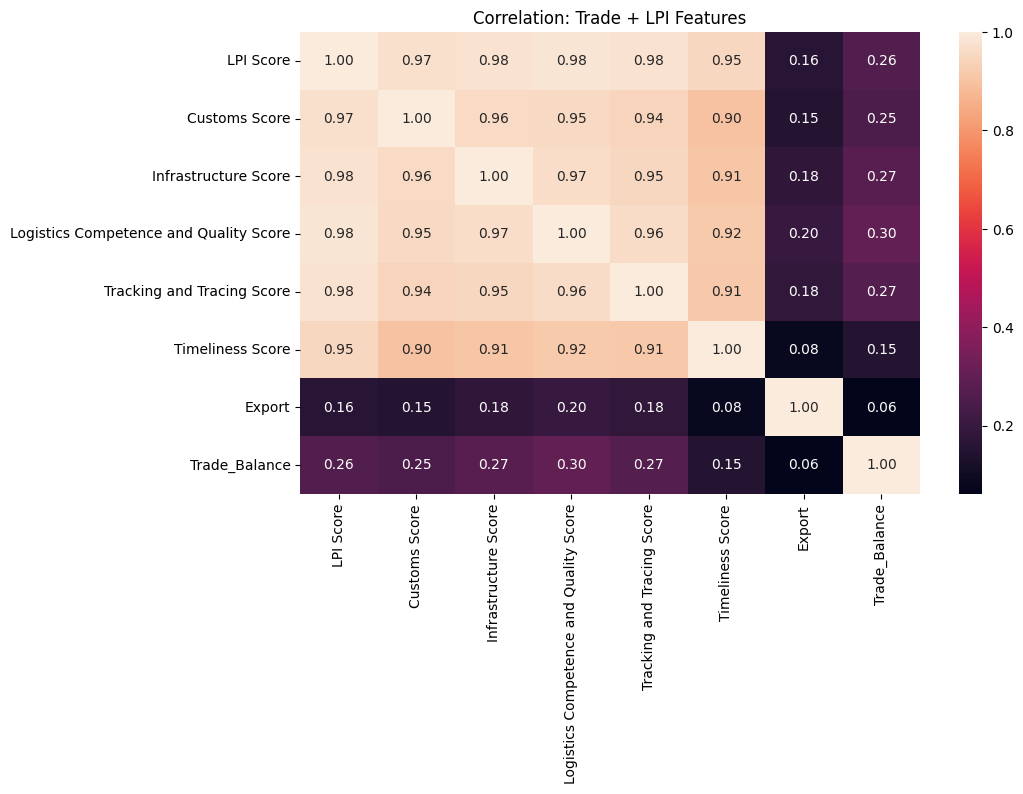

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation: Trade + LPI Features")
plt.show()
#The heat map shows below how a feature has impact on another feature,a perfect score of one or values closer to one shows they are dependent
#while values closer to 0 shows they are not realated at all
#For example the LPI Score and Logistics Competence and Quality score has a value of 0.98 which indicate that these features are correlated meaning 
#these two features are dependent whereas,
#the features export and trade balance have correlation 0.06 which indicate they are not dependent on each other

In [12]:
lpi_corr = corr['LPI Score'].sort_values(ascending=False)
print(lpi_corr)
#numerical values of correlation with LPI Score

LPI Score                                 1.000000
Logistics Competence and Quality Score    0.984357
Infrastructure Score                      0.977348
Tracking and Tracing Score                0.976227
Customs Score                             0.971221
Timeliness Score                          0.950552
Trade_Balance                             0.259335
Export                                    0.163739
Name: LPI Score, dtype: float64


In [13]:
features = [
    'Customs Score',
    'Infrastructure Score',
    'Logistics Competence and Quality Score',
    'Tracking and Tracing Score',
    'Timeliness Score',
    'Export',              # trade factor
    'Trade_Balance'        # trade efficiency
]

X = df[features]
y = df['LPI Score']
X = df[features]
y = df['LPI Score']
X = X.fillna(X.mean())
y = y.fillna(y.mean())
#Mean imputation of missing values for Linear regression

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#Splitting the data for Linear regression with Y on X

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)
#Fitting the curve Y=aX+b

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
#The R2 Score is 0.994 which means the data is good meaning the trade has 99.4% dependent on each other
#the MSE is 0.0017 which likely indicates that the errors predicted by our model is almost close to 0 which we want

R2 Score: 0.9947919356915788
MSE: 0.001716220451000167


In [17]:
import pandas as pd

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)
# The Coeffecients or the slope of each Feature

                                  Feature   Coefficient
2  Logistics Competence and Quality Score  2.348954e-01
4                        Timeliness Score  2.294765e-01
3              Tracking and Tracing Score  1.882720e-01
0                           Customs Score  1.619524e-01
1                    Infrastructure Score  1.482750e-01
6                           Trade_Balance  3.532521e-11
5                                  Export -2.195572e-11


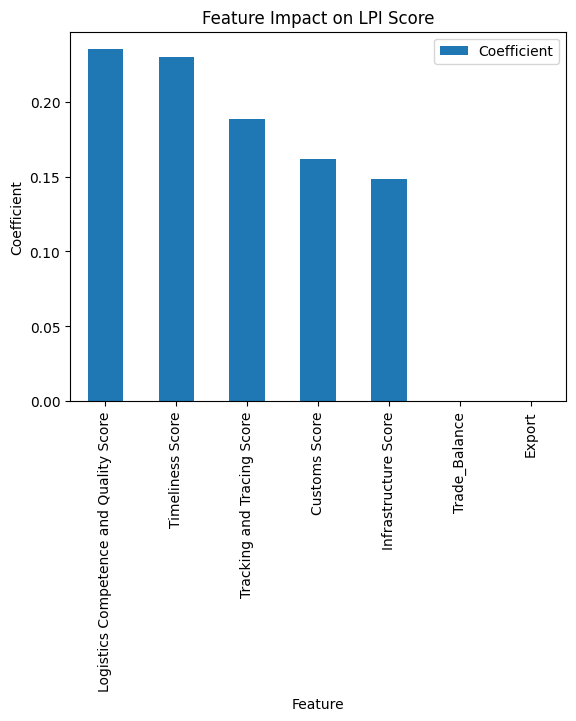

In [18]:
coefficients.plot(kind='bar', x='Feature', y='Coefficient')
plt.title("Feature Impact on LPI Score")
plt.ylabel("Coefficient")
plt.show()
#the Graph show the Impact of features vs LPI Score
#Meaning how data of features changes as lPI score increase by a unit

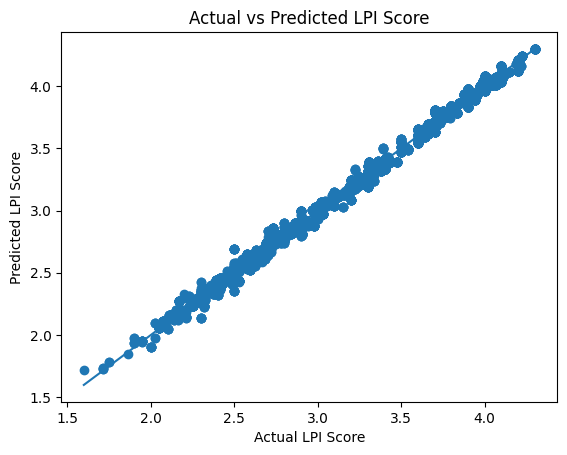

In [19]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual LPI Score")
plt.ylabel("Predicted LPI Score")
plt.title("Actual vs Predicted LPI Score")

# Line for perfect prediction
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()
#the graph below shows the Acutal vs Predicted LPI score which is almost a straight line as our R2 score is close to 1

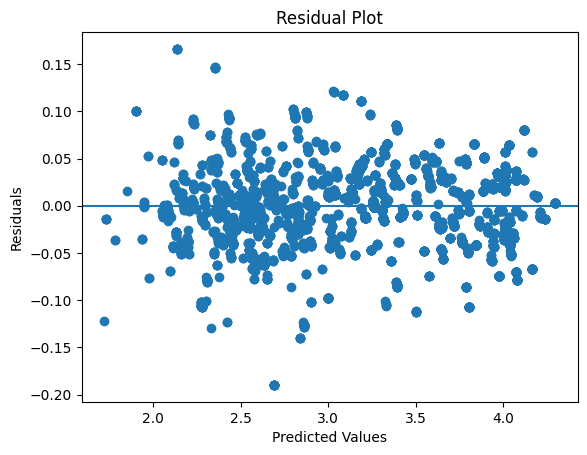

In [20]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.axhline(y=0)
plt.show()
#The Residual plot show how much our data is distrubted which is not by alot considering our values only deviated the most by 0.15 or -0.20

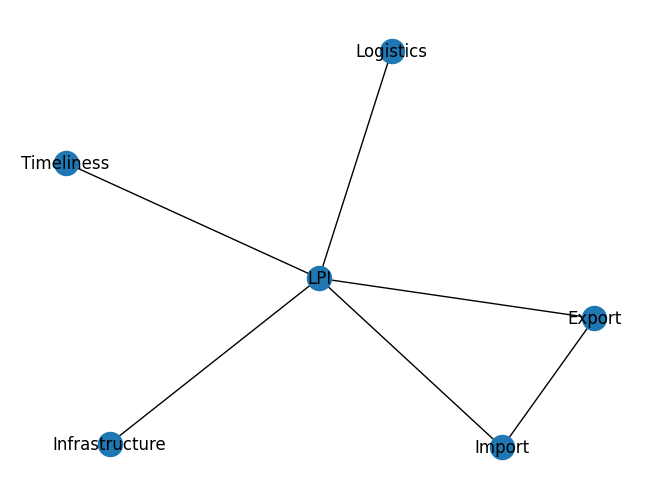

In [21]:
import matplotlib.pyplot as plt
import networkx as nx

# Create graph
G = nx.Graph()

nodes = ["Export", "Import", "LPI", "Infrastructure", "Timeliness", "Logistics"]
edges = [
    ("Export","Import"),
    ("Export","LPI"),
    ("Import","LPI"),
    ("Infrastructure","LPI"),
    ("Timeliness","LPI"),
    ("Logistics","LPI")
]

G.add_nodes_from(nodes)
G.add_edges_from(edges)

# Draw graph
plt.figure()
nx.draw(G, with_labels=True)
plt.savefig("network_graph.png")
plt.show()